In [29]:
import uproot as up
import awkward as ak
import matplotlib.pyplot as plt
import vector as vec
import numpy as np
import pandas as pd

path = "/home/usuario/Madgraph/projects/gg_hh-LQs/"
signal = up.open(path + "signal/Events/run_01_decayed_1/tag_1_delphes_events.root")
sm = up.open("/home/usuario/Madgraph/projects/gg_hh-sm/Events/run_02_decayed_1/tag_1_delphes_events.root")
bg = up.open("/home/usuario/Madgraph/projects/gg_tth_hdecaylep/Events/run_01/tag_1_delphes_events.root")

signal_tree = signal["Delphes"]
sm_tree = sm["Delphes"]
bg_tree = bg["Delphes"]

vec.register_awkward()

In [36]:
def calculo_rangos(lim_inf, lim_sup, data):

    if type(data) == list:

        total_events = sum(len(data_i) for data_i in data)

        debajo = sum(np.sum(data_i < lim_inf) for data_i in data)

        dentro = sum(
            np.sum((data_i >= lim_inf) & (data_i <= lim_sup))
            for data_i in data
        )

        encima = sum(np.sum(data_i > lim_sup) for data_i in data)

        p_debajo = 100 * debajo / total_events
        p_dentro = 100 * dentro / total_events
        p_encima = 100 * encima / total_events

        return lim_inf, lim_sup, p_debajo, p_dentro, p_encima

    else:

        return print("Error: data debe ser una lista de arrays de datos.")

def MissTag_events(data):
    # Me aseguro que data["Jet.BTag"] y data["Jet.TauTag"] sean arrays de numpy solo tomen valores booleanos (0 o 1)
    print(np.unique(ak.flatten(data["Jet.BTag"])))
    print(np.unique(ak.flatten(data["Jet.TauTag"])))

    # Luego, tomo la catidad de eventos que pasan tanto un filtro de b-tag como de tau-tag
    MissTag_events = ak.sum((data["Jet.BTag"]>0) & (data["Jet.TauTag"]>0))

    print('Porcentage of double-tagged events:', round(MissTag_events / ak.sum(data["Jet.TauTag"] > 0) * 100, 2), '%')

def jets_to_vector(data):
    jets = ak.zip({
        "pt": data["Jet.PT"],
        "eta": data["Jet.Eta"],
        "phi": data["Jet.Phi"],
        "mass": data["Jet.Mass"],
        "btag": data["Jet.BTag"],
        "tautag": data["Jet.TauTag"]
    }, with_name="Momentum4D")
    return jets

In [35]:
data_signal = signal_tree.arrays(["Jet.PT","Jet.Eta", "Jet.Phi", "Jet.Mass", "Jet.BTag","Jet.TauTag"])
data_bg = bg_tree.arrays(["Jet.PT","Jet.Eta", "Jet.Phi", "Jet.Mass", "Jet.BTag","Jet.TauTag"])
data_sm = sm_tree.arrays(["Jet.PT","Jet.Eta", "Jet.Phi", "Jet.Mass", "Jet.BTag","Jet.TauTag"])

miss_tag_signal = MissTag_events(data_signal)
miss_tag_bg = MissTag_events(data_bg)
miss_tag_sm = MissTag_events(data_sm)

miss_tag_signal, miss_tag_bg, miss_tag_sm

[0, 1]
[0, 1]
Porcentage of double-tagged events: 6.68 %
[0, 1]
[0, 1]
Porcentage of double-tagged events: 8.64 %
[0, 1]
[0, 1]
Porcentage of double-tagged events: 9.87 %


(None, None, None)

In [37]:
# Defino los cuatrivectores

jets_signal = jets_to_vector(data_signal)
jets_bg = jets_to_vector(data_bg)
jets_sm = jets_to_vector(data_sm)

# Aplico los cortes de cinemática

jets_signal = jets_signal[(jets_signal.pt > 20) & (abs(jets_signal.eta) < 2.5)]
jets_bg = jets_bg[(jets_bg.pt > 20) & (abs(jets_bg.eta) < 2.5)]
jets_sm = jets_sm[(jets_sm.pt > 20) & (abs(jets_sm.eta) < 2.5)]

# Ahora separo en taus y bs

taus_signal  = jets_signal[jets_signal.tautag > 0]
bjets_signal = jets_signal[(jets_signal.btag > 0) & (jets_signal.tautag == 0)]   # Acá elimino el overlap de double tagging

taus_bg  = jets_bg[jets_bg.tautag > 0]
bjets_bg = jets_bg[(jets_bg.btag > 0) & (jets_bg.tautag == 0)]   # Acá elimino el overlap de double tagging

taus_sm  = jets_sm[jets_sm.tautag > 0]
bjets_sm = jets_sm[(jets_sm.btag > 0) & (jets_sm.tautag == 0)]   # Acá elimino el overlap de double tagging

In [38]:
# Selección de eventos con 2 taus y 2 b-jets

def select_events(taus, bjets):
    mask  = (ak.num(taus) >= 2) & (ak.num(bjets) >= 2)
    taus_cut, bjets_cut = taus[mask], bjets[mask]
    tau1, tau2 = taus_cut[:,0], taus_cut[:,1]
    b1, b2     = bjets_cut[:,0], bjets_cut[:,1]
    return tau1, tau2, b1, b2


tau1_sl, tau2_sl, b1_sl, b2_sl = select_events(taus_signal, bjets_signal)
tau1_bg, tau2_bg, b1_bg, b2_bg = select_events(taus_bg, bjets_bg)
tau1_sm, tau2_sm, b1_sm, b2_sm = select_events(taus_sm, bjets_sm)

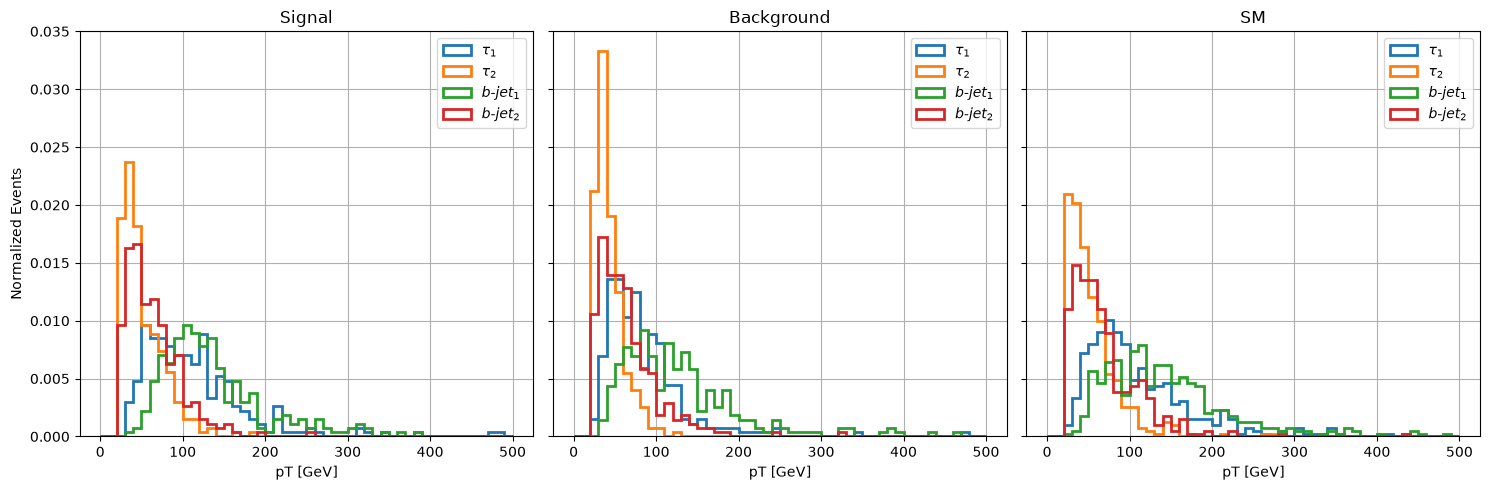

In [48]:
import matplotlib.pyplot as plt

sets = [("Signal", tau1_sl, tau2_sl, b1_sl, b2_sl),
        ("Background", tau1_bg, tau2_bg, b1_bg, b2_bg),
        ("SM", tau1_sm, tau2_sm, b1_sm, b2_sm)]

labels = [r"$\tau_1$", r"$\tau_2$", r"$b\text{-}jet_1$", r"$b\text{-}jet_2$"]
kw = dict(bins=50, range=(0,500), density=True, histtype="step", linewidth=2)

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

axes[0].hist(ak.to_numpy(tau1_sl.pt), label=labels[0], **kw)
axes[0].hist(ak.to_numpy(tau2_sl.pt), label=labels[1], **kw)
axes[0].hist(ak.to_numpy(b1_sl.pt), label=labels[2], **kw)
axes[0].hist(ak.to_numpy(b2_sl.pt), label=labels[3], **kw)
axes[0].set_title("Signal")
axes[0].set_ylabel("Normalized Events")
axes[0].set_xlabel("pT [GeV]")
axes[0].legend()

axes[1].hist(ak.to_numpy(tau1_bg.pt), label=labels[0], **kw)
axes[1].hist(ak.to_numpy(tau2_bg.pt), label=labels[1], **kw)
axes[1].hist(ak.to_numpy(b1_bg.pt), label=labels[2], **kw)
axes[1].hist(ak.to_numpy(b2_bg.pt), label=labels[3], **kw)
axes[1].set_title("Background")
axes[1].set_xlabel("pT [GeV]")
axes[1].legend()

axes[2].hist(ak.to_numpy(tau1_sm.pt), label=labels[0], **kw)
axes[2].hist(ak.to_numpy(tau2_sm.pt), label=labels[1], **kw)
axes[2].hist(ak.to_numpy(b1_sm.pt), label=labels[2], **kw)
axes[2].hist(ak.to_numpy(b2_sm.pt), label=labels[3], **kw)
axes[2].set_title("SM")
axes[2].set_xlabel("pT [GeV]")
axes[2].legend()

for ax in axes:
        ax.grid()

fig.tight_layout()
fig.savefig("pt_distribution.png", dpi=300)
plt.show()

In [49]:
# Distribucion de masas invariante de los pares tau-tau y b-b

LQ_m_tautau = (tau1_sl + tau2_sl).mass
LQ_m_bb     = (b1_sl + b2_sl).mass
LQ_m_hh     = (tau1_sl + tau2_sl + b1_sl + b2_sl).mass

SM_m_tautau = (tau1_sm + tau2_sm).mass
SM_m_bb     = (b1_sm + b2_sm).mass
SM_m_hh     = (tau1_sm + tau2_sm + b1_sm + b2_sm).mass

BG_m_tautau = (tau1_bg + tau2_bg).mass
BG_m_bb     = (b1_bg + b2_bg).mass
BG_m_hh     = (tau1_bg + tau2_bg + b1_bg + b2_bg).mass

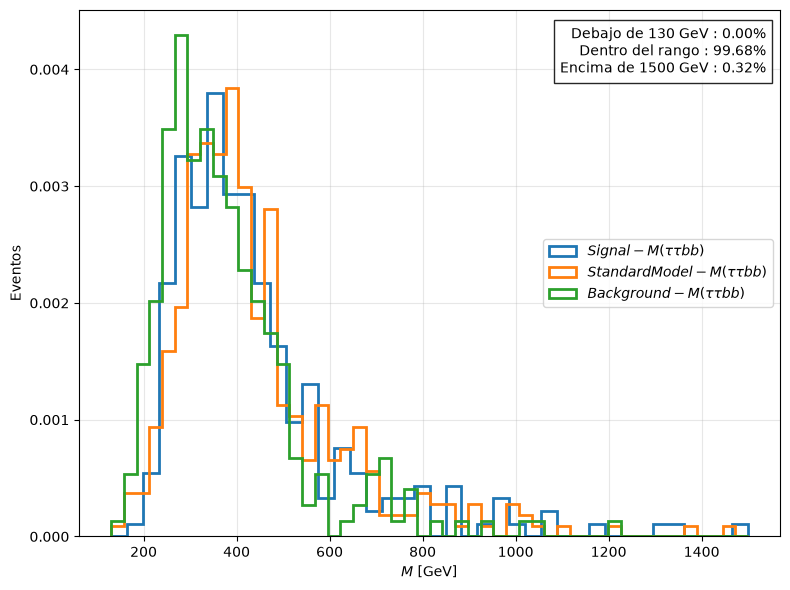

In [ ]:
data = [LQ_m_hh, SM_m_hh, BG_m_hh]

lim_inf, lim_sup, p_debajo, p_dentro, p_encima = calculo_rangos(130,1500, data)

plt.figure(figsize=(8,6))

texto = (
    f"Debajo de {lim_inf} GeV : {p_debajo:.2f}%\n"
    f"Dentro del rango : {p_dentro:.2f}%\n"
    f"Encima de {lim_sup} GeV : {p_encima:.2f}%"
)

plt.text(
    0.98, 0.97,
    texto,
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.85)
)

# --- Subplot izquierdo: señal ---
plt.hist(LQ_m_hh, bins=40, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Signal - M(\tau \tau b b)$")
plt.hist(SM_m_hh, bins=50, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Standard Model - M(\tau \tau b b)$")
plt.hist(BG_m_hh, bins=50, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Background - M(\tau \tau b b)$")
plt.xlabel(r"$M$ [GeV]")
plt.ylabel("Eventos")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("InvariantMass_distribution.png", dpi=300)
plt.show()

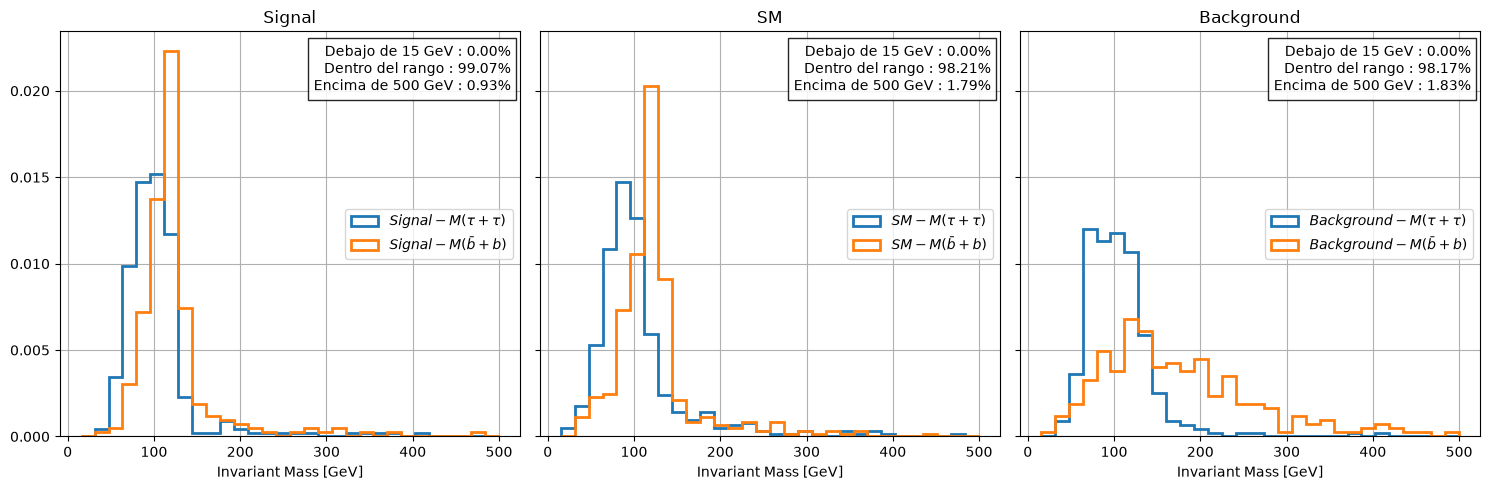

In [77]:
data0 = [LQ_m_tautau, LQ_m_bb]
data1 = [SM_m_tautau, SM_m_bb]
data2 = [BG_m_tautau, BG_m_bb]

lim_inf_0, lim_sup_0, p_debajo_0, p_dentro_0, p_encima_0 = calculo_rangos(15,500, data0)
lim_inf_1, lim_sup_1, p_debajo_1, p_dentro_1, p_encima_1 = calculo_rangos(15,500, data1)
lim_inf_2, lim_sup_2, p_debajo_2, p_dentro_2, p_encima_2 = calculo_rangos(15,500, data2)


fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

texto0 = (f"Debajo de {lim_inf_0} GeV : {p_debajo_0:.2f}%\n"f"Dentro del rango : {p_dentro_0:.2f}%\n"f"Encima de {lim_sup_0} GeV : {p_encima_0:.2f}%")
texto1 = (f"Debajo de {lim_inf_1} GeV : {p_debajo_1:.2f}%\n"f"Dentro del rango : {p_dentro_1:.2f}%\n"f"Encima de {lim_sup_1} GeV : {p_encima_1:.2f}%")
texto2 = (f"Debajo de {lim_inf_2} GeV : {p_debajo_2:.2f}%\n"f"Dentro del rango : {p_dentro_2:.2f}%\n"f"Encima de {lim_sup_2} GeV : {p_encima_2:.2f}%")

axes[0].text(
    0.98, 0.97,
    texto0,
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.85)
)

axes[1].text(
    0.98, 0.97,
    texto1,
    transform=axes[1].transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.85)
)

axes[2].text(
    0.98, 0.97,
    texto2,
    transform=axes[2].transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.85)
)

axes[0].hist(LQ_m_tautau, bins=30, density=True, range=(lim_inf_0, lim_sup_0), histtype="step", linewidth=2, label=r"$Signal - M(\tau + \tau)$")
axes[0].hist(LQ_m_bb, bins=30, density=True, range=(lim_inf_0, lim_sup_0), histtype="step", linewidth=2, label=r"$Signal - M(\bar{b} + b)$")
axes[0].set_title("Signal")
axes[0].set_xlabel("Invariant Mass [GeV]")
axes[0].legend(loc = 'center right')

axes[1].hist(SM_m_tautau, bins=30, density=True, range=(lim_inf_1, lim_sup_1), histtype="step", linewidth=2, label=r"$SM - M(\tau + \tau)$")
axes[1].hist(SM_m_bb, bins=30, density=True, range=(lim_inf_1, lim_sup_1), histtype="step", linewidth=2, label=r"$SM - M(\bar{b} + b)$")
axes[1].set_title("SM")
axes[1].set_xlabel("Invariant Mass [GeV]")
axes[1].legend(loc = 'center right')

axes[2].hist(BG_m_tautau, bins=30, density=True, range=(lim_inf_2, lim_sup_2), histtype="step", linewidth=2, label=r"$Background - M(\tau + \tau)$")
axes[2].hist(BG_m_bb, bins=30, density=True, range=(lim_inf_2, lim_sup_2), histtype="step", linewidth=2, label=r"$Background - M(\bar{b} + b)$")
axes[2].set_title("Background")
axes[2].set_xlabel("Invariant Mass [GeV]")
axes[2].legend(loc = 'center right')

for ax in axes:
        ax.grid()

fig.tight_layout()
plt.savefig("MassControl.png", dpi=300)
plt.show()

In [51]:
# Distribución de DeltaR entre los pares tau-tau y b-b

DeltaR_tautau = tau1_sl.deltaR(tau2_sl)
DeltaR_bb = b1_sl.deltaR(b2_sl)

DeltaR_tautau_SM = tau1_sm.deltaR(tau2_sm)
DeltaR_bb_SM = b1_sm.deltaR(b2_sm)

DeltaR_tautau_BG = tau1_bg.deltaR(tau2_bg)
DeltaR_bb_BG = b1_bg.deltaR(b2_bg)


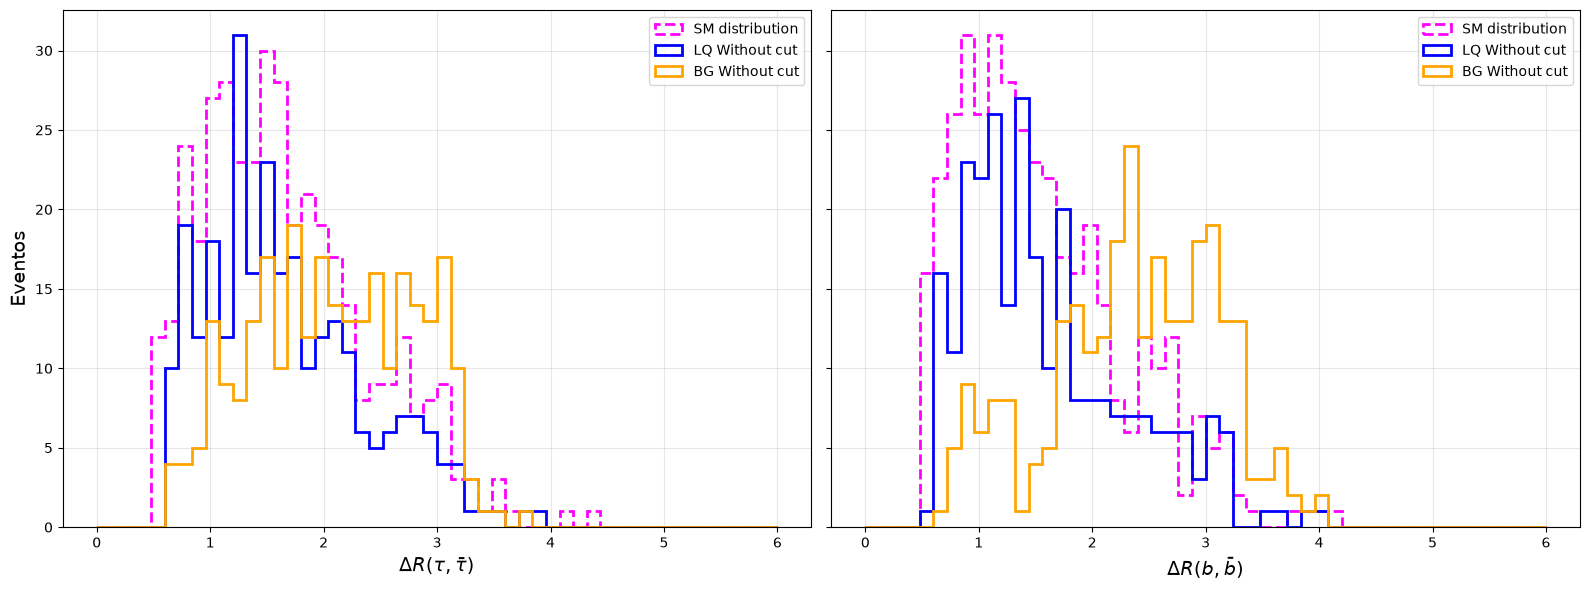

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# ==========================================================
# Primer gráfico
# ==========================================================

ax1.hist(DeltaR_tautau_SM,bins=50,range=(0,6),histtype="step", density = False,color="magenta",linestyle="--",linewidth=2,label="SM distribution")

ax1.hist(DeltaR_tautau,bins=50,range=(0,6),histtype="step", density = False,color="blue",linewidth=2,label="LQ Without cut")

ax1.hist(DeltaR_tautau_BG,bins=50,range=(0,6),histtype="step", density = False,color="orange",linewidth=2,label="BG Without cut")

ax1.set_xlabel(r"$\Delta R(\tau,\bar \tau)$", fontsize=14)
ax1.set_ylabel("Eventos", fontsize=14)
ax1.grid(alpha=0.3)
ax1.legend(fontsize=10)

# ==========================================================
# Segundo gráfico
# ==========================================================

ax2.hist(DeltaR_bb_SM,bins=50,range=(0,6),histtype="step", density = False,color="magenta",linestyle="--",linewidth=2,label="SM distribution")

ax2.hist(DeltaR_bb,bins=50,range=(0,6),histtype="step", density = False,color="blue",linewidth=2,label="LQ Without cut")

ax2.hist(DeltaR_bb_BG,bins=50,range=(0,6),histtype="step", density = False,color="orange",linewidth=2,label="BG Without cut")

ax2.set_xlabel(r"$\Delta R(b,\bar b)$", fontsize=14)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=10)

# ==========================================================
# Ajustes finales
# ==========================================================

plt.tight_layout()

plt.savefig("DeltaR_distribution.png", dpi=300)

plt.show()

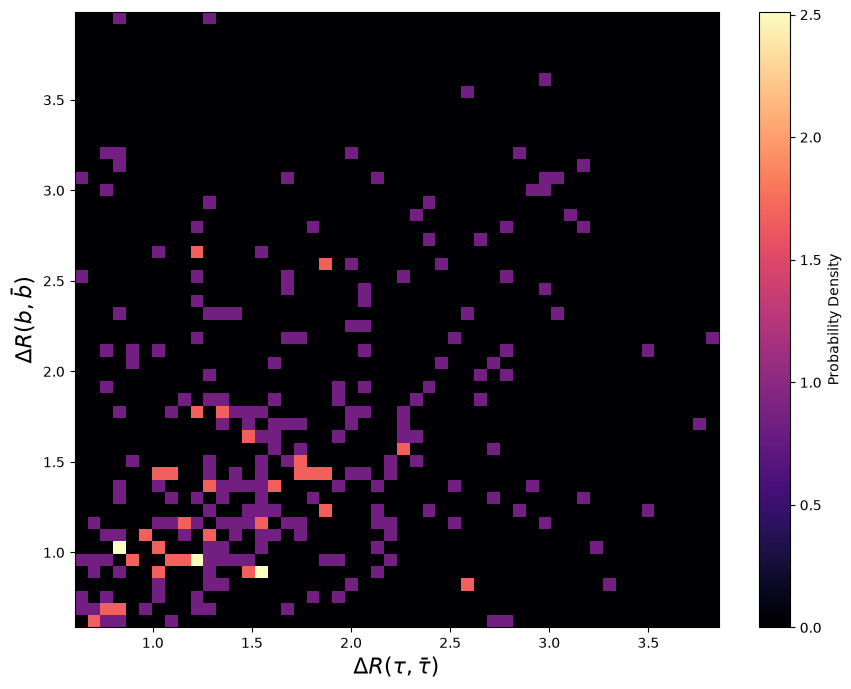

In [57]:
# Grafico 2D de DeltaR(tau tau) vs DeltaR(b b)

plt.figure(figsize=(9,7))

plt.hist2d(ak.to_numpy(DeltaR_tautau), ak.to_numpy(DeltaR_bb), bins=50, cmap="magma", density=True)
# plt.hist2d(DeltaR_tautau_SM, DeltaR_bb_SM, bins=50, cmap="viridis", density=True)

plt.colorbar(label="Probability Density")
plt.xlabel(r"$\Delta R(\tau,\bar \tau)$", fontsize=16)
plt.ylabel(r"$\Delta R(b,\bar b)$", fontsize=16)

plt.tight_layout()
plt.savefig("2D-DeltaR_distribution.png", dpi=300)
plt.show()